In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings("ignore")

In [14]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

In [4]:
# Sample 2D dataset
from sklearn.datasets import make_moons
X, y = make_moons(n_samples = 300, noise = 0.2, random_state = 42)

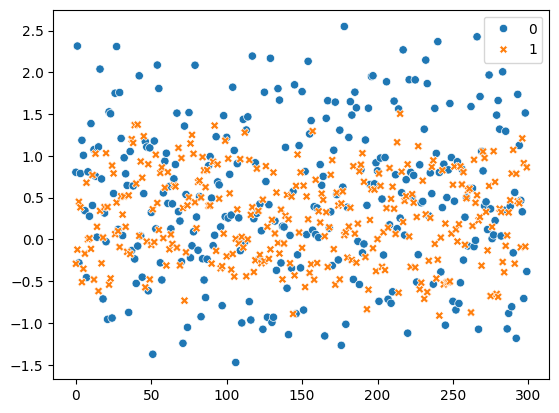

In [6]:
sns.scatterplot(X) 
plt.legend()
plt.show()

In [7]:
# Create pipeline: polynomial + logistic regression
model = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    LogisticRegression()
)

In [8]:
model.fit(X , y)

,steps,"[('polynomialfeatures', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,3
,interaction_only,False
,include_bias,False
,order,'C'
,penalty,'l2'
,dual,False
,tol,0.0001


In [9]:
def plot_decision_boundary(model, X, y, resolution = 0.01):
    x_min, x_max = X[ : , 0].min() - 1, X[ : , 0].max() + 1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, resolution),
                         np.arange(y_min, y_max, resolution))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap='bwr')
    plt.title("Polynomial Logistic Regression")
    plt.show()


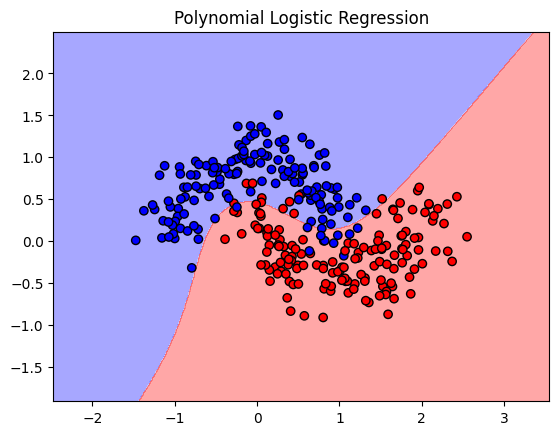

In [10]:
plot_decision_boundary(model , X , y)

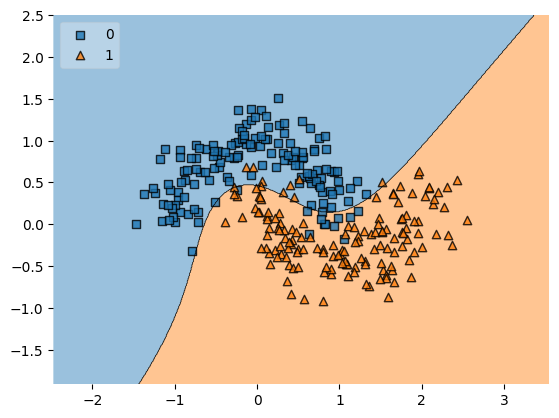

In [12]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X , y , model , legend = 2)
plt.show()

In [15]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
np.mean(cross_val_score(model , X , y , scoring = 'accuracy', cv = 10))

np.float64(0.9266666666666667)

In [18]:
# making a method to simulate the train test and draw boundary plot 
def simulate(X, y, polynomial_degree = 2): 
    # do the train test split 
    X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.1 , random_state = 42)
    
    # make the pipeline 
    pipeline = make_pipeline(
        PolynomialFeatures(degree = polynomial_degree , include_bias = False), 
        LogisticRegression()
    )
    
    # Fit the pipeline on training data
    pipeline.fit(X_train , y_train)
    # Predict and evaluate on test set 
    y_pred = pipeline.predict(X_test)

    cross_val = np.mean(cross_val_score(pipeline , X , y , scoring = 'accuracy', cv = 10))
    accuracy = accuracy_score(y_test , y_pred)
    
    plot_decision_regions(X , y, clf = pipeline , legend = 2)
    plt.title(f"Degree = {polynomial_degree}, Test Accuracy = {np.round(accuracy, 4)}, CV = {np.round(cross_val, 4)}")
    plt.grid(True)
    plt.show()

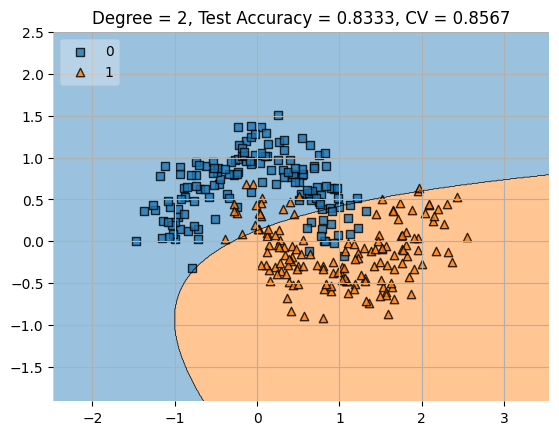

In [19]:
simulate(X , y , polynomial_degree = 2)

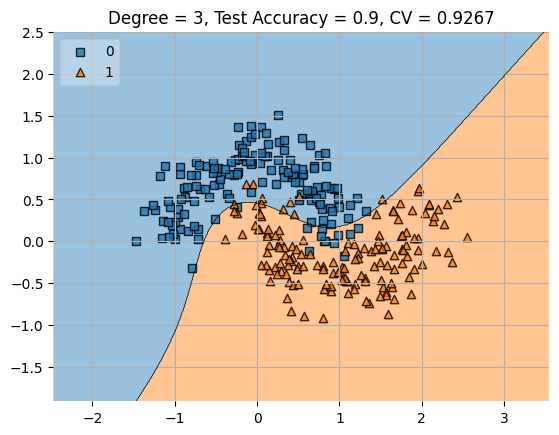

In [20]:
simulate(X , y , polynomial_degree = 3)

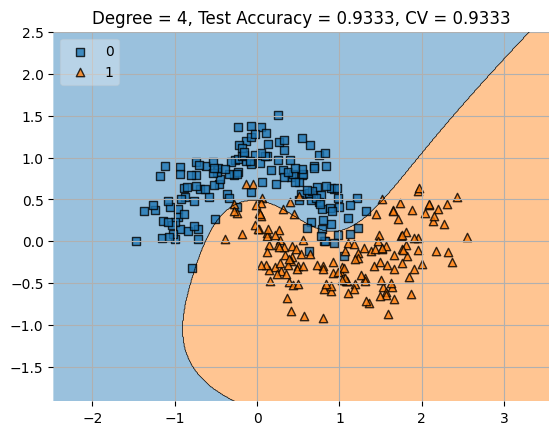

In [21]:
simulate(X , y , polynomial_degree = 4)

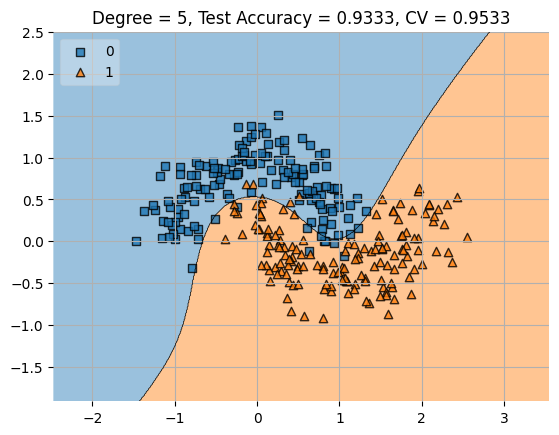

In [22]:
simulate(X , y , polynomial_degree = 5)